# Тетрадь №1 по ПСИИ
### Выполнил студент группы БФБО-06-24 Петров Артем

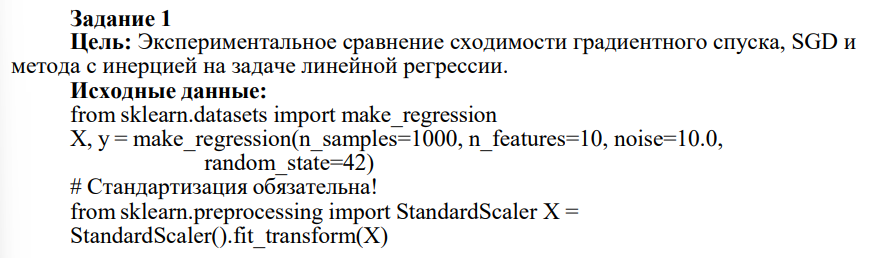

In [25]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
X, y = make_regression(n_samples = 1000, n_features = 10, noise = 10, random_state = 42)
# Стандартизация обязательна!
from sklearn.preprocessing import StandardScaler
StandardScaler().fit_transform(X)

array([[ 1.53152453,  0.8767533 , -0.71340648, ...,  1.05567023,
        -0.2609192 , -0.76608273],
       [ 0.52211118,  1.24971293, -1.78107808, ..., -0.52110102,
         0.74343252, -0.98913772],
       [-0.66321975,  0.14562249,  0.17127751, ...,  0.24518105,
        -0.36189885, -0.61364504],
       ...,
       [ 0.41781837, -0.84024363,  1.68536042, ...,  0.23904916,
        -0.50750747, -0.17209224],
       [-0.26296357, -1.3845607 ,  0.17509104, ..., -0.02701976,
        -0.63133528,  0.66744099],
       [ 0.52421764,  0.36655853, -0.26044401, ..., -2.3880297 ,
         0.90952324, -0.42073517]])

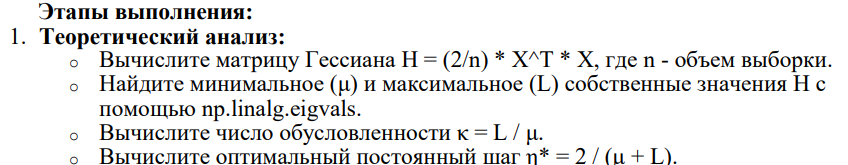

In [34]:
# Вычисление матрицы Гессиана:
def Gessian(X):
    n = X.shape[0] # объём выборки
    return (2/n) * X.T @ X
H = Gessian(X)
# Собственные значения:
eigvals = np.linalg.eigvals(H)
# Минимальное:
Mew = min(eigvals)
# Максимальное:
L = max(eigvals)
# Число обусловленности:
k = L / Mew
# Оптимальный постоянный шаг:
Eta = 2 / (Mew + L)

# Вывод найденных значений:
print(F'Список с собственными значениями: \n{eigvals};\n\n минимальное собственное значение: \n{Mew};\n\n Максимальное собственное значение: \n{L};\n\n Число обусловленности: \n{k};\n\n Оптимальный постоянный шаг: \n{Eta};')

Список с собственными значениями: 
[2.34130744 1.6818012  1.74339905 2.22857231 1.90822971 1.94346602
 2.00622314 2.12709322 2.07013028 2.08658999];

 минимальное собственное значение: 
1.6818011985747705;

 Максимальное собственное значение: 
2.3413074430656424;

 Число обусловленности: 
1.3921428079904838;

 Оптимальный постоянный шаг: 
0.4971280117318694;


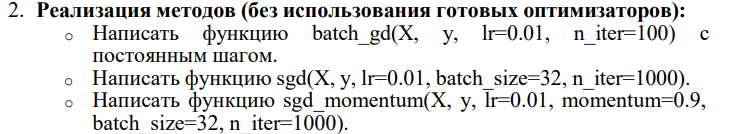

In [4]:
# Создадим ф-цию потерь MSE для удобства и большей наглядности:
def MSE(X, y, w):
    return np.mean((X @ w - y.reshape(-1, 1))**2)

def batch_gd(X, y, lr = 0.01, n_iter = 100):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    losses = []
    for i in range(n_iter):
        # Вычисление градиента
        grad = (2 / n_samples) * X.T @ (X @ w - y.reshape(-1, 1))
        # Обновление весов:
        w -= lr * grad
        # Вычисление MSE на всей выборке
        losses.append(MSE(X, y, w))
    return losses

def sgd(X, y, lr=0.01, batch_size=32, n_iter=1000):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    losses = []
    for i in range(n_iter):
        # Выбор случайных значений (batch_size)
        idx = np.random.choice(n_samples, batch_size, replace = False)
        # присвоение данных и преобразование массива y в одномернвц массив
        Xb, yb = X[idx], y[idx].reshape(-1,1)
        # Вычисление градиента
        grad = (2/len(idx)) * Xb.T @ (Xb @ w - yb)
        # обновление весов
        w -= lr * grad
        # Вычисление MSE на выборке
        losses.append(MSE(X, y, w))
    return losses

def sgd_momentum(X, y, lr=0.01, momentum = 0.9, batch_size = 32, n_iter = 1000):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    v = np.zeros_like(w)
    losses = []
    for i in range(n_iter):
        idx = np.random.choice(n_samples, batch_size, replace = False)
        Xb, yb = X[idx], y[idx].reshape(-1,1)
        grad = (2/len(idx)) * Xb.T @ (Xb @ w - yb)
        v = momentum * v - lr * grad
        w += v
        losses.append(MSE(X, y, w))
    return losses

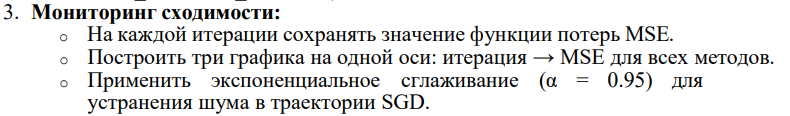

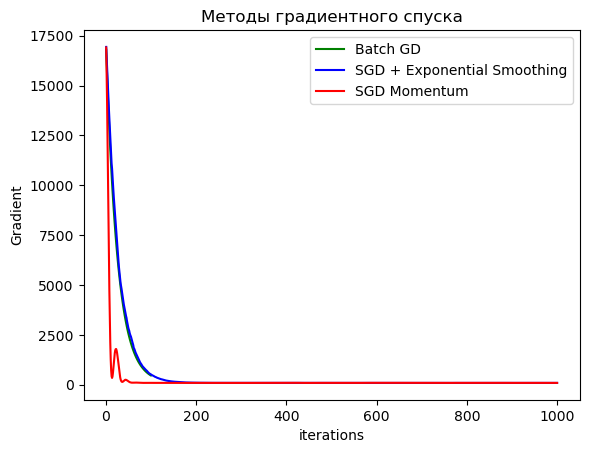

In [81]:
# Ф-ция для экспоненциального сглаживания:
def exp_smooth(alpha, series):
    res = [series[0]]
    for i in range(1, len(series)):
        res.append(alpha * series[i] + (1 - alpha) * res[i-1])
    return res

# Теперь создадим график:
plt.plot(list(range(1, 101)), batch_gd(X, y, 0.01, 100), color = 'g', label = 'Batch GD')
plt.plot(list(range(1, 1001)), exp_smooth(0.95, sgd(X, y, 0.01, 32, 1000)), color = 'b', label = 'SGD + Exponential Smoothing')
plt.plot(list(range(1, 1001)), sgd_momentum(X, y, 0.01, 0.9, 32, 1000), color = 'r', label = 'SGD Momentum')
plt.xlabel('iterations')
plt.ylabel('Gradient')
plt.title("Методы градиентного спуска")
plt.legend()
plt.show()

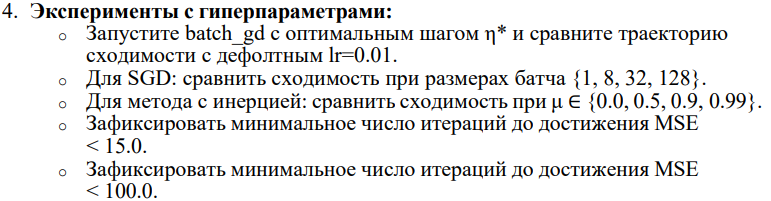

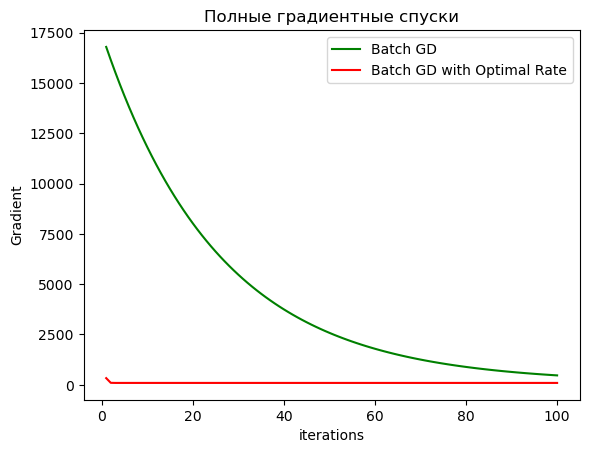

In [35]:
# Сравним Траекторию дефолтного полного градиента и с оптимальным шагом:
plt.plot(list(range(1, 101)), batch_gd(X, y, 0.01, 100), color = 'g', label = 'Batch GD')
plt.plot(list(range(1, 101)), batch_gd(X, y, Eta, 100), color = 'r', label = 'Batch GD with Optimal Rate')
plt.xlabel('iterations')
plt.ylabel('Gradient')
plt.title("Полные градиентные спуски")
plt.legend()
plt.show()

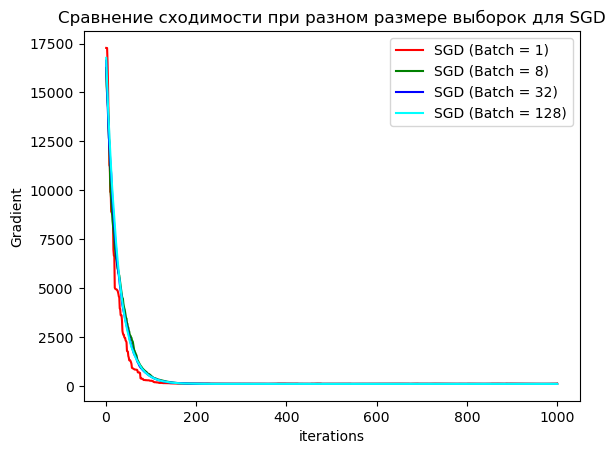

In [86]:
# Теперь сравним сходимость разных батчей для Стохастического градиентного спуска:
plt.plot(list(range(1, 1001)), sgd(X, y, 0.01, 1, 1000), color = 'r', label = 'SGD (Batch = 1)')
plt.plot(list(range(1, 1001)), sgd(X, y, 0.01, 8, 1000), color = 'g', label = 'SGD (Batch = 8)')
plt.plot(list(range(1, 1001)), sgd(X, y, 0.01, 32, 1000), color = 'b', label = 'SGD (Batch = 32)')
plt.plot(list(range(1, 1001)), sgd(X, y, 0.01, 128, 1000), color = 'cyan', label = 'SGD (Batch = 128)')
plt.xlabel('iterations')
plt.ylabel('Gradient')
plt.title("Сравнение сходимости при разном размере выборок для SGD")
plt.legend()
plt.show()

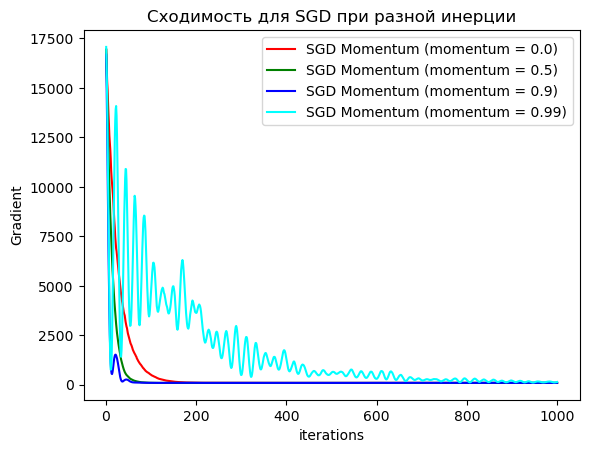

In [87]:
# Далее сравним сходимость для SGD с разной инерцией:
plt.plot(list(range(1, 1001)), sgd_momentum(X, y, 0.01, 0.0, 32, 1000), color = 'r', label = 'SGD Momentum (momentum = 0.0)')
plt.plot(list(range(1, 1001)), sgd_momentum(X, y, 0.01, 0.5, 32, 1000), color = 'g', label = 'SGD Momentum (momentum = 0.5)')
plt.plot(list(range(1, 1001)), sgd_momentum(X, y, 0.01, 0.9, 32, 1000), color = 'b', label = 'SGD Momentum (momentum = 0.9)')
plt.plot(list(range(1, 1001)), sgd_momentum(X, y, 0.01, 0.99, 32, 1000), color = 'cyan', label = 'SGD Momentum (momentum = 0.99)')
plt.xlabel('iterations')
plt.ylabel('Gradient')
plt.title("Сходимость для SGD при разной инерции")
plt.legend()
plt.show()

In [31]:
# Теперь зафиксируем минимальное число итераций до достижения MSE < 15 и MSE < 100:
# Создадим ф-цию, которая поможет найти нужные значения в списке со значениями MSE:

def iters_to_threshold(losses, threshold):
    # Данная ф-ция возвращает номер первой итерации (начиная с 1) и значение MSE на этой итерации,
    # на которой loss < threshold. Если не достигнуто, возвращает строку "Не достигнуто" и мин. число из достигнутых.
    for i, loss in enumerate(losses):
        if loss < threshold:
            return [i + 1, loss] 
    return [f'За {len(losses)} итераций не достигнуто', f'Минимальное значение = {min(losses)}']
    
# Возьмём стандартные значения для ф-ций:
losses_batch = batch_gd(X, y, 0.01, 1000)
losses_sgd = sgd(X, y, lr=0.01, batch_size=32, n_iter=1000)
losses_sgdm = sgd_momentum(X, y, lr=0.01, momentum=0.9, batch_size=32, n_iter=1000)

print(f"Batch GD: до MSE < 100: {iters_to_threshold(losses_batch, 100.0)[0]}; MSE на итерации {iters_to_threshold(losses_batch, 100.0)[0]} = {iters_to_threshold(losses_batch, 100.0)[1]};")
print(f"до MSE < 15: {iters_to_threshold(losses_batch, 15.0)[0]}; МSE на итерации = {iters_to_threshold(losses_batch, 15.0)[1]}\n")

print(f"SGD: до MSE < 100: {iters_to_threshold(losses_sgd, 100.0)[0]}; MSE на итерации {iters_to_threshold(losses_sgd, 100.0)[0]} = {iters_to_threshold(losses_sgd, 100.0)[1]};")
print(f"до MSE < 15: {iters_to_threshold(losses_sgd, 15.0)[0]}; МSE на итерации = {iters_to_threshold(losses_sgd, 15.0)[1]}\n")

print(f"SGD Momentum: до MSE < 100: {iters_to_threshold(losses_sgdm, 100.0)[0]}; MSE на итерации {iters_to_threshold(losses_sgdm, 100.0)[0]} = {iters_to_threshold(losses_sgdm, 100.0)[1]};")
print(f"до MSE < 15: {iters_to_threshold(losses_sgdm, 15.0)[0]}; МSE на итерации = {iters_to_threshold(losses_sgdm, 15.0)[1]}\n")

Batch GD: до MSE < 100: 209; MSE на итерации 209 = 99.89238524330415;
до MSE < 15: За 1000 итераций не достигнуто; МSE на итерации = Минимальное значение = 93.01549048733465

SGD: до MSE < 100: 203; MSE на итерации 203 = 99.99030511043671;
до MSE < 15: За 1000 итераций не достигнуто; МSE на итерации = Минимальное значение = 93.09400633186952

SGD Momentum: до MSE < 100: 74; MSE на итерации 74 = 99.5880124728;
до MSE < 15: За 1000 итераций не достигнуто; МSE на итерации = Минимальное значение = 93.60536192574489



In [29]:
'''
Как бы функции не преобразовывались и сколько бы итераций не производилось, мин. 
значение MSE не опускалось ниже 93. По сему было принятно решение найти
теоретический минимум для этих данных:
'''
# Аналитическое решение (нормальные уравнения)
# Нахождение обратных весов через обратную матрицу:
w_opt = np.linalg.inv(X.T @ X) @ X.T @ y
# Предсказание с использованием оптимальных весов
y_opt = X @ w_opt
# Минимально возможное значение MSE:
mse_min = np.mean((y_opt - y)**2)
print(f"Теоретический минимум MSE: {mse_min}")

Теоретический минимум MSE: 93.0154904873255


Краткий вывод: На представленных данных невозможно достичь значение MSE < 15. Но к минимальному теоретическому значению MSE ближе всего оказалось значение полного градиентного спуска на 1000-й итерации.

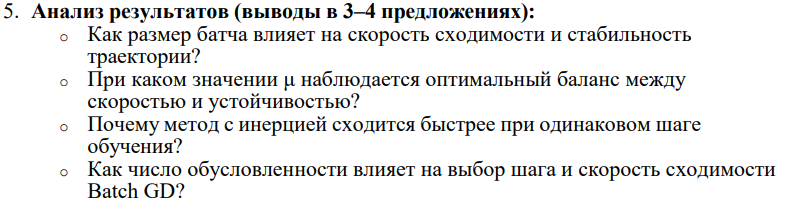

## Как размер батча влияет на скорость сходимости и стабильность траектории?

Чем меньше размер батча (выборки) - тем быстрее сходимость, но так же и ниже стабильность траектории. График "Сравнение сходимости при разном размере выборок для SGD" наглядно показывает разность в скорости и стабильности, самое нестабильное и быстрое - батч размером 1, самое стабильное и медленное - батч размером 128.

## При каком значении Эта наблюдается оптимальный баланс между скорость и устойчивостью?

Если судить по графику "Сходимость для SGD при разной инерции", значение Эта = 0.5 самое оптимальное. Потому что остальные значения проявляют некую нестабильность (расхождение), не считая значения 0.0, ведь оно, по своей сути, отменяет инерцию.

## Почему метод с инерцией сходится быстрее при одинаковом шаге обучения?

Потому что инерция гасит собою "неровности и ямы", то есть, если значение градиента мало - обычный SGD будет делать крошечные шаги, в то время как версия с инерцией будет их накавливать и через несколько шагов значение станет заметным и произойдёт более быстрый "проскок". Так же инерция усредняет шумные градиенты.

## Как число обусловленности влияет на выбор шага и скорость сходимости Batch GD?

Чем больше число обусловленности - тем уже диапазон "безопасных" шагов, оптимальный шаг находится ближе к 2/L, но меньше чем 2/L (в диапазоне 0 < Eta < 2/L). Скорость сходимости растёт линейно с числом обусловленности, к примеру, для K = 100 нужно в 100 раз больше итераций, чем при K = 1.